In [1]:
from langgraph.graph import START, END, StateGraph
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_core.runnables import Runnable
from collections.abc import Sequence

In [2]:
class State(TypedDict):
    messages: Sequence[BaseMessage]

In [3]:
state = State(messages = [HumanMessage("Could you tell me how to improve shoulder mobility?")])

In [4]:
state["messages"][0].pretty_print()

================================ Human Message =================================

Could you tell me how to improve shoulder mobility?


In [5]:
from langchain_openai.chat_models import ChatOpenAI
import sys
sys.path.append("..")
import config

chat = ChatOpenAI(
    model = "openai/gpt-4",
    seed = 365,
    api_key=config.apiKey2,
    temperature = 0,
    max_tokens = 100,
    base_url="https://openrouter.ai/api/v1"
)

In [6]:
def chatbot(state: State) -> State:
    res = chat.invoke(state["messages"])
    res.pretty_print()
    return State(messages = [res])

In [7]:
graph = StateGraph(State)

In [8]:
graph.add_node("chatbot", chatbot)
graph.add_edge(START, "chatbot")
graph.add_edge("chatbot", END)

In [9]:
graphc = graph.compile()

In [10]:
isinstance(graphc, Runnable), isinstance(graph, Runnable)

(True, False)

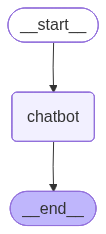

In [11]:
graphc

In [12]:
graphc.invoke(state)

================================== Ai Message ==================================

1. Shoulder Circles: Stand straight and rotate your shoulders in a circular motion, first forward, then backward. This helps to loosen the shoulder joints.

2. Arm Circles: Extend your arms out to the sides and make small circles in the air, first forward, then backward. Gradually increase the size of the circles.

3. Doorway Stretch: Stand in an open doorway. Place your hands at shoulder height on either side of the door frame. Keeping your hands in place, lean


{'messages': [AIMessage(content='1. Shoulder Circles: Stand straight and rotate your shoulders in a circular motion, first forward, then backward. This helps to loosen the shoulder joints.\n\n2. Arm Circles: Extend your arms out to the sides and make small circles in the air, first forward, then backward. Gradually increase the size of the circles.\n\n3. Doorway Stretch: Stand in an open doorway. Place your hands at shoulder height on either side of the door frame. Keeping your hands in place, lean', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 17, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}, 'cost': 0.00651, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.00651, 'upstream_inference_prompt_cost': 0.00051, 'upstream_in

In [13]:
%mypy

UsageError: Line magic function `%mypy` not found.


#### Conditional edges

In [14]:
from typing import Literal

In [15]:
def askQ(state: State) -> State:
    print("What is your question?")
    return State(messages = [HumanMessage(input())])

In [17]:
def askanQ(state: State) -> State:
    print("Would you like to ask one more question (yes/no)?")
    return State(messages = [HumanMessage(input())])

In [38]:
### Routing function
def routing(state: State) -> Literal["ask_question", "__end__"]:
    if state["messages"][0].content == "yes":
        return "ask_question"
    else:
        return "__end__"

In [39]:
g = StateGraph(State)
g.add_node("ask_question", askQ)
g.add_node("chatbot", chatbot)
g.add_node("ask_another_question", askanQ) 

g.add_edge(START, "ask_question")
g.add_edge("ask_question", "chatbot")
g.add_edge("chatbot", "ask_another_question")
g.add_conditional_edges(source = "ask_another_question", path = routing)

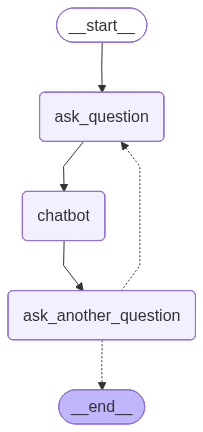

In [40]:
gc = g.compile()
gc

In [42]:
gc.invoke(State(messages = []))

What is your question?


 Tell me a short story about a mushroom enthusiast who died whilst running from a bee


================================== Ai Message ==================================

Once upon a time, in the quaint town of Bumblebee, lived a man named Gilbert. Gilbert was a peculiar man, known for his eccentric hobbies and his profound love for mushrooms. He was a mushroom enthusiast, spending his days exploring the dense forests surrounding the town, hunting for rare and exotic mushrooms.

Gilbert was a solitary man, preferring the company of his beloved mushrooms over people. He had an encyclopedic knowledge of all things fungi, and his home was filled with books
Would you like to ask one more question (yes/no)?


 yes


What is your question?


 How did Gilbert die to a bee?


================================== Ai Message ==================================

Without specific context, it's hard to provide an accurate answer. However, in general, a person could potentially die from a bee sting if they have a severe allergic reaction, known as anaphylaxis. This can cause difficulty breathing, a drop in blood pressure, and cardiac arrest. If Gilbert had such an allergy and was stung by a bee, it could potentially be fatal if not treated immediately.
Would you like to ask one more question (yes/no)?


 no


{'messages': [HumanMessage(content='no', additional_kwargs={}, response_metadata={})]}

#### Memory

In [45]:
# Up: messages[0].content => no memory, replacing state values after each node, default behaviour of the 

from typing import Annotated # attach metadata to a type
from langchain_core.messages import AIMessage
from langgraph.graph import add_messages

In [46]:
# append values to existing states
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages] # reducer function

In [47]:
def askQ(state: State) -> State:
    for i in state["messages"]:
        i.pretty_print() 
    q = "What is your question?"
    print(q)
    return State(messages = [AIMessage(q), HumanMessage(input())])

In [48]:
def askanQ(state: State) -> State:
    for i in state["messages"]:
        i.pretty_print() 
    q = "Whould you like to ask another question? (yes/no)"
    print(q)
    return State(messages = [AIMessage(q), HumanMessage(input())])

In [50]:
def routing(state: State) -> Literal["ask_question", "__end__"]:
    if state["messages"][-1].content == "yes":
        return "ask_question"
    else:
        return "__end__"


In [51]:
g = StateGraph(State)
g.add_node("ask_question", askQ)
g.add_node("chatbot", chatbot)
g.add_node("ask_another_question", askanQ) 
g.add_edge(START, "ask_question")
g.add_edge("ask_question", "chatbot")
g.add_edge("chatbot", "ask_another_question")
g.add_conditional_edges(source = "ask_another_question", path = routing)
gc = g.compile()
gc.invoke(State(messages = []))

What is your question?


 In a max of 4 sentences tell a short story about a gorilla who died fighting the giraffe


================================== Ai Message ==================================

In the heart of the African jungle, a mighty gorilla named Kibo found himself in a territorial dispute with a towering giraffe named Malaika. The two giants clashed, their battle echoing through the wilderness, as Kibo fought fiercely to protect his family. Despite his strength and courage, Kibo was fatally wounded by Malaika's powerful kicks. His sacrifice, however, was not in vain, as his family managed to escape, forever remembering Kibo as their brave protector.
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

In a max of 4 sentences tell a short story about a gorilla who died fighting the giraffe
================================== Ai Message ==================================

In the heart of the African jungle, a mighty gorilla named Kibo found himself in a territ

 yes


================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

In a max of 4 sentences tell a short story about a gorilla who died fighting the giraffe
================================== Ai Message ==================================

In the heart of the African jungle, a mighty gorilla named Kibo found himself in a territorial dispute with a towering giraffe named Malaika. The two giants clashed, their battle echoing through the wilderness, as Kibo fought fiercely to protect his family. Despite his strength and courage, Kibo was fatally wounded by Malaika's powerful kicks. His sacrifice, however, was not in vain, as his family managed to escape, forever remembering Kibo as their brave protector.
================================== Ai Message ==================================

Whould you like to ask another question? (yes/no)
================================ Human 

 Why did Kibo sacrifice himself?


================================== Ai Message ==================================

Kibo, the gorilla, sacrificed himself to protect his family from Malaika, the giraffe. He understood that the safety of his family was at stake and he was willing to risk his own life to ensure their survival. His selfless act allowed his family to escape the dangerous situation.
================================== Ai Message ==================================

What is your question?
================================ Human Message =================================

In a max of 4 sentences tell a short story about a gorilla who died fighting the giraffe
================================== Ai Message ==================================

In the heart of the African jungle, a mighty gorilla named Kibo found himself in a territorial dispute with a towering giraffe named Malaika. The two giants clashed, their battle echoing through the wilderness, as Kibo fought fiercely to protect his family. Despite his strength 

 no


{'messages': [AIMessage(content='What is your question?', additional_kwargs={}, response_metadata={}, id='adfc200c-0713-4db2-99f3-c3c450d140fa'),
  HumanMessage(content='In a max of 4 sentences tell a short story about a gorilla who died fighting the giraffe', additional_kwargs={}, response_metadata={}, id='789ebc35-0f64-4735-8e2a-02f2fcad773e'),
  AIMessage(content="In the heart of the African jungle, a mighty gorilla named Kibo found himself in a territorial dispute with a towering giraffe named Malaika. The two giants clashed, their battle echoing through the wilderness, as Kibo fought fiercely to protect his family. Despite his strength and courage, Kibo was fatally wounded by Malaika's powerful kicks. His sacrifice, however, was not in vain, as his family managed to escape, forever remembering Kibo as their brave protector.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 98, 'prompt_tokens': 37, 'total_tokens': 135, 'completion_tokens

In [52]:
# Pre-implemented class 
from langgraph.graph import MessagesState
# remove state object definition ( state = State(...) ) and replace all State occurences with MessagesState, could create a custom class extending it